In [12]:
import sys, pdb, numpy as np, astropy
import pylab as pl
from workdirs import *
from importlib import reload
from astropy import constants as cons, units as un
sys.path.append('../pysrc/')

In [27]:
import FIRE_files as ff
import my_utils as u

In [8]:
#f = np.load('/Users/jonathanstern/Dropbox/jonathanmain/CGM/rapidCoolingCGM/pyobj/no_yt_analysis/profiler_m12i_md_7100_z0.1377.npz')

In [33]:
m12i_dir = simdir + 'metal_diffusion/m12i_r7100/'
iSnapshots = np.arange(277,600,30)
AHF_fn = m12i_dir + 'halo/ahf/halo_00000_smooth.dat'
Rimp2Rvirs = np.arange(0.1,1.01,0.02)
I_Ha = np.zeros((len(iSnapshots),len(Rimp2Rvirs)))

In [5]:
for iiSnapshot,iSnapshot in enumerate(iSnapshots):
    sim = ff.Snapshot_meta('m12i','md','7100',m12i_dir+'output/',AHF_fn,
                           iSnapshot=iSnapshot)
    snapshot = ff.Snapshot(sim,loadAll=False)
    profiler = ff.Snapshot_profiler(snapshot)
    print(profiler.rvir)
    HaEmission = profiler.profile1D('Halpha_emission','VW') #erg/cm^3/s
    profiler.tofile()
    #project
    for iRimp,Rimp in enumerate(Rimp2Rvirs*profiler.rvir):
        rs = profiler.rs_midbins()
        coeff = (1-(Rimp/rs)**2)
        new_coeff = np.where(coeff > 0, coeff ** -0.5, 0.0)
        drs = profiler.drs_midbins()
        ind = new_coeff.nonzero()[0][0]
        drs[ind] *= (rs[ind]-Rimp) / (rs[ind]-rs[ind-1])
        I_Ha[iiSnapshot,iRimp] = np.nansum(HaEmission * drs *un.kpc.to('cm')*new_coeff) #erg/cm^2/s
I_Ha *= 2.4e-11 / 4*np.pi #erg/cm^2/s/arcsec
#project

NameError: name 'iSnapshots' is not defined

In [39]:
I_Ha=np.array([[9.76548799e-18, 7.01371924e-18, 5.15912195e-18, 4.13437642e-18,
        3.23312754e-18, 2.68539456e-18, 2.16544527e-18, 1.65480251e-18,
        1.28978872e-18, 1.01719046e-18, 8.35969813e-19, 7.13767636e-19,
        6.52438833e-19, 5.47977737e-19, 4.76067772e-19, 4.09814885e-19,
        3.58366732e-19, 3.12583006e-19, 2.82433608e-19, 2.57660399e-19,
        2.28354255e-19, 2.08872753e-19, 2.06578204e-19, 2.01853513e-19,
        2.00058731e-19, 1.82749018e-19, 1.65663457e-19, 1.37074570e-19,
        1.23807875e-19, 1.15677378e-19, 1.07657284e-19, 1.08081016e-19,
        1.04319634e-19, 9.76886113e-20, 9.00675939e-20, 7.73857851e-20,
        6.23702491e-20, 5.03374727e-20, 3.63230178e-20, 2.40828829e-20,
        1.66119745e-20, 1.29620825e-20, 1.22367094e-20, 1.21176182e-20,
        1.05822654e-20, 7.67539040e-21],
       [5.05107457e-18, 3.56569626e-18, 2.73922431e-18, 2.03991495e-18,
        1.35111924e-18, 1.04456476e-18, 8.27926784e-19, 6.24155348e-19,
        4.27997259e-19, 3.38272395e-19, 2.55343479e-19, 2.04216281e-19,
        1.82933252e-19, 1.57910382e-19, 1.43504034e-19, 1.35339585e-19,
        1.29717438e-19, 1.21583196e-19, 1.03786725e-19, 9.33872903e-20,
        8.27924378e-20, 7.18600772e-20, 6.32001164e-20, 5.00680655e-20,
        4.40475306e-20, 4.02939539e-20, 3.92557035e-20, 3.73406099e-20,
        3.68027910e-20, 3.75094445e-20, 3.83852165e-20, 4.04095083e-20,
        4.33411187e-20, 4.64085867e-20, 4.00725831e-20, 2.66656983e-20,
        1.75572167e-20, 1.09572480e-20, 7.37636011e-21, 6.23382452e-21,
        5.41840743e-21, 4.39564701e-21, 3.88351837e-21, 3.71198888e-21,
        3.57353848e-21, 3.47538563e-21],
       [6.54285373e-18, 3.50555014e-18, 2.02959460e-18, 1.35523952e-18,
        9.81419449e-19, 7.95533400e-19, 6.08573214e-19, 4.46434338e-19,
        3.20471465e-19, 2.34165795e-19, 1.80200977e-19, 1.38831424e-19,
        1.17083805e-19, 8.37093715e-20, 6.59622933e-20, 5.40866897e-20,
        4.52312148e-20, 4.13483997e-20, 3.88837401e-20, 3.66521625e-20,
        3.42450349e-20, 3.52824910e-20, 2.55026666e-20, 1.20434973e-20,
        8.03636201e-21, 5.77484700e-21, 4.55122799e-21, 3.71740314e-21,
        3.26219662e-21, 2.94707345e-21, 2.77786410e-21, 2.78370517e-21,
        2.78121963e-21, 2.71725194e-21, 2.68238732e-21, 2.64645848e-21,
        2.61766801e-21, 2.58486570e-21, 2.54438406e-21, 2.46866676e-21,
        2.36197885e-21, 2.27398471e-21, 2.22080743e-21, 1.88499363e-21,
        1.36180779e-21, 1.06173734e-21],
       [3.30160940e-18, 1.98175659e-18, 1.23242455e-18, 8.54846904e-19,
        6.17999303e-19, 4.59716254e-19, 3.34966221e-19, 2.41908528e-19,
        1.82813958e-19, 1.42916309e-19, 1.11260371e-19, 8.87713428e-20,
        7.05587282e-20, 5.16500345e-20, 4.22931472e-20, 3.20117104e-20,
        2.81252488e-20, 2.58469321e-20, 2.17253570e-20, 1.76542372e-20,
        1.32755261e-20, 9.42437069e-21, 7.82739469e-21, 5.45672235e-21,
        3.21298275e-21, 2.17349386e-21, 1.98421799e-21, 1.80462530e-21,
        1.73267183e-21, 1.67440672e-21, 1.62083644e-21, 1.60466205e-21,
        1.59071286e-21, 1.56556173e-21, 1.53710908e-21, 1.52057869e-21,
        1.50677446e-21, 1.48014125e-21, 1.46584070e-21, 1.46968937e-21,
        1.47414271e-21, 1.48150425e-21, 1.49084491e-21, 1.50583682e-21,
        1.53050890e-21, 1.57175343e-21],
       [2.04578267e-18, 1.18915213e-18, 7.15048490e-19, 4.76441784e-19,
        2.73640749e-19, 2.04818402e-19, 1.60310426e-19, 1.25708518e-19,
        1.06390384e-19, 7.84306747e-20, 5.49726634e-20, 3.74921491e-20,
        2.86206839e-20, 1.86121139e-20, 1.49575789e-20, 1.30052180e-20,
        1.20737801e-20, 1.09679768e-20, 9.90038286e-21, 6.80438256e-21,
        4.42028142e-21, 3.44003628e-21, 3.05666706e-21, 2.60234426e-21,
        2.42545378e-21, 2.33207232e-21, 2.31284018e-21, 2.28670867e-21,
        2.18818081e-21, 1.75801129e-21, 1.59349237e-21, 1.54775957e-21,
        1.55563021e-21, 1.57501774e-21, 1.59525281e-21, 1.61407566e-21,
        1.63868419e-21, 1.67255130e-21, 1.71253107e-21, 1.75919932e-21,
        1.81679593e-21, 1.88594258e-21, 1.96965579e-21, 2.07314246e-21,
        2.20408143e-21, 2.37724552e-21],
       [7.01890622e-19, 3.20082085e-19, 2.02775512e-19, 1.42497606e-19,
        8.97869902e-20, 8.03558024e-20, 6.48249833e-20, 4.89226847e-20,
        3.71615782e-20, 3.28328104e-20, 2.92721559e-20, 2.84712383e-20,
        2.72913645e-20, 1.98218336e-20, 1.30251221e-20, 8.87386358e-21,
        5.60666530e-21, 3.60832494e-21, 2.77575478e-21, 2.23897257e-21,
        1.77760002e-21, 1.43510699e-21, 1.25691505e-21, 1.13727936e-21,
        1.07744535e-21, 1.01470892e-21, 9.83393432e-22, 9.55787617e-22,
        9.41679576e-22, 9.24437951e-22, 9.11435963e-22, 9.14714114e-22,
        9.20297861e-22, 9.26441417e-22, 9.35828133e-22, 9.56545607e-22,
        9.89799083e-22, 1.03313604e-21, 1.08963759e-21, 1.16170097e-21,
        1.26037491e-21, 1.38855726e-21, 1.57787497e-21, 1.79617495e-21,
        1.39764555e-21, 5.26378861e-22],
       [6.14380097e-19, 3.24166496e-19, 1.37972688e-19, 6.59734734e-20,
        4.73398786e-20, 4.26674424e-20, 3.05343488e-20, 2.27383308e-20,
        1.90133433e-20, 1.73034111e-20, 1.42929247e-20, 1.15468487e-20,
        1.04755434e-20, 8.70754192e-21, 8.76109605e-21, 8.27729654e-21,
        7.55088230e-21, 6.93827879e-21, 6.33652637e-21, 5.70348252e-21,
        5.29937643e-21, 4.96687104e-21, 4.37396492e-21, 3.41879581e-21,
        3.31341630e-21, 1.98969224e-21, 7.05984226e-22, 1.91880429e-22,
        1.34905953e-22, 1.14269073e-22, 9.75760416e-23, 9.06881616e-23,
        8.59788654e-23, 8.39561124e-23, 8.29845048e-23, 8.20090433e-23,
        7.83162735e-23, 7.36662738e-23, 7.02417022e-23, 6.79312487e-23,
        6.64023893e-23, 6.53872504e-23, 6.49644604e-23, 6.48212520e-23,
        6.48905656e-23, 6.51291021e-23],
       [2.60180501e-19, 1.02843388e-19, 4.90489549e-20, 3.01303541e-20,
        1.77956278e-20, 1.62199729e-20, 1.40989913e-20, 1.27610961e-20,
        1.16312352e-20, 1.04220645e-20, 1.01588938e-20, 8.11851970e-21,
        6.66668379e-21, 5.84077760e-21, 5.11928915e-21, 5.25490425e-21,
        5.63948066e-21, 4.83785762e-21, 2.86394856e-21, 1.60406861e-21,
        1.10778513e-21, 1.05595229e-21, 1.00331596e-21, 8.39310292e-22,
        7.53876979e-22, 7.29996008e-22, 7.32362382e-22, 7.13979558e-22,
        6.78789832e-22, 6.99418380e-22, 7.17149185e-22, 7.43298324e-22,
        7.77118628e-22, 8.21101988e-22, 8.75968680e-22, 9.55795717e-22,
        1.07679493e-21, 1.10939903e-21, 7.37656026e-22, 2.73220226e-22,
        1.36955497e-22, 1.16512247e-22, 1.09509365e-22, 1.12453584e-22,
        1.11857546e-22, 8.17565703e-23],
       [2.11127159e-19, 8.81558282e-20, 4.36316350e-20, 2.39741018e-20,
        1.48926266e-20, 1.11022579e-20, 6.04655815e-21, 4.12944284e-21,
        3.15259495e-21, 2.81566030e-21, 2.55138187e-21, 2.47578204e-21,
        2.47182242e-21, 2.27362018e-21, 2.23491644e-21, 2.35214426e-21,
        2.23178290e-21, 1.89802384e-21, 1.69416774e-21, 1.64695871e-21,
        1.66462270e-21, 1.66321378e-21, 1.70209766e-21, 1.62702221e-21,
        1.49691011e-21, 1.11462903e-21, 7.29696336e-22, 5.75065739e-22,
        5.94191386e-22, 5.45486113e-22, 4.34067493e-22, 4.45436749e-22,
        4.61650930e-22, 4.81391694e-22, 5.05943650e-22, 5.36545892e-22,
        5.75732256e-22, 6.28467411e-22, 7.04719060e-22, 8.16675180e-22,
        9.47370466e-22, 7.31924277e-22, 3.00030770e-22, 5.37978076e-23,
        2.23045204e-23, 2.19381067e-23],
       [9.61647477e-20, 4.47896000e-20, 1.91744754e-20, 1.03780638e-20,
        8.12956466e-21, 7.90483286e-21, 6.05138189e-21, 5.73164384e-21,
        5.11331032e-21, 3.69345541e-21, 2.82970388e-21, 2.63885462e-21,
        2.22789069e-21, 1.82438249e-21, 1.76653550e-21, 1.59693542e-21,
        1.43965605e-21, 1.36778288e-21, 1.25768052e-21, 1.10322856e-21,
        9.63838985e-22, 8.04554115e-22, 7.01055527e-22, 6.12717874e-22,
        5.90533169e-22, 5.83904343e-22, 5.85378087e-22, 5.91403656e-22,
        6.11667423e-22, 6.46498061e-22, 6.88280921e-22, 7.58936211e-22,
        8.44441976e-22, 7.80127466e-22, 5.14420884e-22, 3.91088560e-22,
        3.94587147e-22, 4.00142355e-22, 3.99507544e-22, 2.81919375e-22,
        1.28918257e-22, 7.43546320e-23, 6.72581854e-23, 6.64131920e-23,
        6.67240121e-23, 6.71171650e-23],
       [4.17260793e-20, 1.61601916e-20, 7.23170340e-21, 6.46628329e-21,
        4.40702901e-21, 4.00322824e-21, 2.60511598e-21, 1.87241353e-21,
        1.31413603e-21, 1.16708873e-21, 1.01241729e-21, 9.19524495e-22,
        8.56364423e-22, 7.54307808e-22, 7.37143584e-22, 7.21843094e-22,
        7.09946701e-22, 6.77343821e-22, 6.58690073e-22, 5.74468879e-22,
        5.38701397e-22, 4.98052863e-22, 4.92153914e-22, 5.05028371e-22,
        4.53520821e-22, 4.11910607e-22, 4.15707440e-22, 4.25835728e-22,
        4.54205036e-22, 4.93267729e-22, 5.11379965e-22, 3.62853325e-22,
        2.82159514e-22, 2.78623641e-22, 2.91470909e-22, 3.19614859e-22,
        3.49412020e-22, 3.41048887e-22, 2.10705770e-22, 9.32905729e-23,
        5.95230833e-23, 5.39639634e-23, 5.24815167e-23, 5.23504205e-23,
        5.28679018e-23, 5.34101940e-23]])

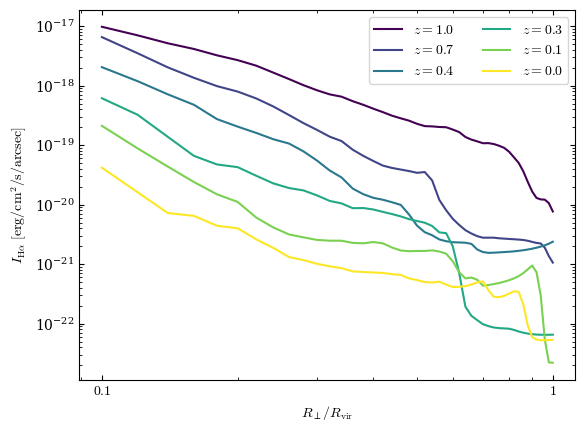

In [42]:
ax = pl.subplot(111)
for i in range(11):
    if i%2==1: continue
    pl.loglog(Rimp2Rvirs, I_Ha[i,:],
              c=pl.get_cmap('viridis')(i/10),
             label=r'$z=%.1f$'%ff.z_from_iSnapshot(iSnapshots[i]))
pl.legend(ncol=2)
pl.xlabel(r'$R_\perp / R_{\rm vir}$')
pl.ylabel(r'$I_{\rm H\alpha}\ [{\rm erg/cm^2/s/arcsec}]$')
ax.xaxis.set_major_formatter(u.arilogformatter)
pl.savefig('I_Ha.png')

In [38]:
np.arange(4).nonzero()[0][0]

1

In [43]:
os.getcwd()

'/Users/jonathanstern/Dropbox/github_repositories/gizmo_analysis/ipynb'

In [46]:
arr = np.arange(0,1,1e-3)
xs,zs = np.meshgrid(arr,arr)

In [47]:
rs = (xs**2+zs**2)**0.5
costheta = zs/rs

/var/folders/l2/fknwc0nn1636skl21t587m400000gn/T/ipykernel_8769/722430495.py:2: RuntimeWarning: invalid value encountered in divide
  costheta = zs/rs


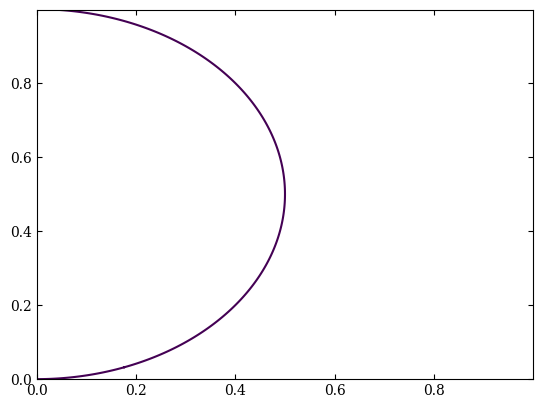

In [49]:
pl.contour(arr,arr,costheta/rs,[1])